In [ ]:
!wget https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip

--2026-06-14 10:53:40--  https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.200.181.207, 2600:1413:5000:12a1::317f, 2600:1413:5000:12ae::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.200.181.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M   155MB/s    in 8.2s    

2026-06-14 10:53:48 (95.6 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



In [ ]:
!unzip -q kagglecatsanddogs_5340.zip

In [ ]:
!ls

 CDLA-Permissive-2.0.pdf      PetImages        sample_data
 kagglecatsanddogs_5340.zip  'readme[1].txt'


In [ ]:
!ls PetImages

Cat  Dog


In [ ]:
!ls PetImages/Cat | wc -l

12501


In [ ]:
!ls PetImages/Dog | wc -l

12501


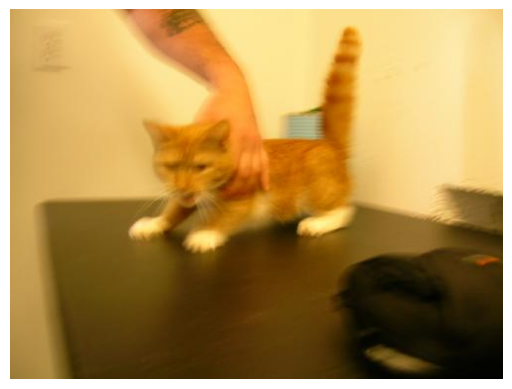

In [ ]:
from matplotlib import pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('PetImages/Cat/0.jpg')

plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
print(img.shape)

(375, 500, 3)


In [ ]:
print(img)

[[[203 164  87]
  [203 164  87]
  [204 165  88]
  ...
  [240 201 122]
  [239 200 121]
  [238 199 120]]

 [[203 164  87]
  [203 164  87]
  [204 165  88]
  ...
  [240 201 122]
  [239 200 121]
  [239 200 121]]

 [[203 164  87]
  [203 164  87]
  [204 165  88]
  ...
  [241 202 123]
  [240 201 122]
  [239 200 121]]

 ...

 [[153 122  55]
  [153 122  55]
  [153 122  55]
  ...
  [  2   2   0]
  [  2   2   0]
  [  2   2   0]]

 [[152 121  54]
  [152 121  54]
  [152 121  54]
  ...
  [  1   1   0]
  [  1   1   0]
  [  1   1   0]]

 [[151 120  53]
  [151 120  53]
  [152 121  54]
  ...
  [  1   1   0]
  [  1   1   0]
  [  1   1   0]]]


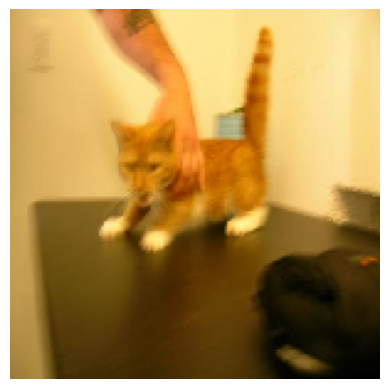

In [ ]:
from tensorflow.keras.preprocessing import image

img_resized = image.load_img(
    'PetImages/Cat/0.jpg',
    target_size=(150,150)
)

plt.imshow(img_resized)
plt.axis('off')
plt.show()

In [ ]:
import numpy as np

img_array = np.array(img_resized)

print(img_array.shape)

(150, 150, 3)


In [ ]:
print(img_array[0][0])

[203 164  87]


In [ ]:
img_normalized = img_array / 255.0
print(img_normalized[0][0])

[0.79607843 0.64313725 0.34117647]


In [ ]:
print(img_normalized.min())
print(img_normalized.max())

0.0
1.0


In [ ]:
import numpy as np

img_batch = np.expand_dims(img_normalized, axis=0)

print(img_batch.shape)

(1, 150, 150, 3)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(150,150,3)
    )
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

values = tf.constant([-10,-5,0,7,15])

print(tf.nn.relu(values).numpy())

[ 0  0  0  7 15]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(150,150,3)
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.layers import Flatten

model.add(Flatten())

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.layers import Dense

model.add(Dense(128, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,636,481 (40.57 MB)

 Trainable params: 10,636,481 (40.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    "PetImages",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 20000 images belonging to 2 classes.


In [ ]:
validation_generator = train_datagen.flow_from_directory(
    "PetImages",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 5000 images belonging to 2 classes.


In [ ]:
print(train_generator.class_indices)

{'Cat': 0, 'Dog': 1}


In [ ]:
import os
from PIL import Image

num_skipped = 0

for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("PetImages", folder_name)

    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)

        try:
            with Image.open(fpath) as img:
                img.verify()
        except Exception:
            num_skipped += 1
            os.remove(fpath)

print("Deleted corrupted images:", num_skipped)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Deleted corrupted images: 4


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "PetImages",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    "PetImages",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.layers import Dropout
model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

ValueError: You must call `compile()` before using the model.

In [ ]:
model.save("cat_dog_model.keras")

In [ ]:
!ls

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load model
model = load_model("cat_dog_model.keras")

# Image path
img_path = "WhatsApp Image 2026-06-14 at 3.06.23 PM.jpeg"

# Load and resize image
img = image.load_img(img_path, target_size=(150,150))

# Display image
plt.imshow(img)
plt.axis('off')
plt.show()

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

print("Raw Prediction:", prediction)

if prediction[0][0] > 0.5:
    print("🐶 DOG")
    print("Confidence:", round(prediction[0][0] * 100, 2), "%")
else:
    print("🐱 CAT")
    print("Confidence:", round((1 - prediction[0][0]) * 100, 2), "%")

ValueError: File not found: filepath=cat_dog_model.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!ls

 CDLA-Permissive-2.0.pdf      PetImages        sample_data
 kagglecatsanddogs_5340.zip  'readme[1].txt'


In [ ]:
from PIL import Image
import os

num_skipped = 0

for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("PetImages", folder_name)

    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)

        try:
            with Image.open(fpath) as img:
                img.verify()
        except:
            num_skipped += 1
            os.remove(fpath)

print("Deleted corrupted images:", num_skipped)

Deleted corrupted images: 0


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    "PetImages",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 20000 images belonging to 2 classes.


In [ ]:
validation_generator = train_datagen.flow_from_directory(
    "PetImages",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 4998 images belonging to 2 classes.


In [ ]:
print(train_generator.samples)
print(validation_generator.samples)
print(train_generator.class_indices)

20000
4998
{'Cat': 0, 'Dog': 1}


In [ ]:
base_model = MobileNetV2(
    input_shape=(150,150,3),
    include_top=False,
    weights='imagenet'
)

/tmp/ipykernel_410/338274072.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[early_stop]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 185s 295ms/step - accuracy: 0.9604 - loss: 0.0952 - val_accuracy: 0.9588 - val_loss: 0.1021
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 174s 278ms/step - accuracy: 0.9647 - loss: 0.0880 - val_accuracy: 0.9526 - val_loss: 0.1071
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 176s 281ms/step - accuracy: 0.9660 - loss: 0.0839 - val_accuracy: 0.9568 - val_loss: 0.1006


In [ ]:
model.save("cat_dog_mobilenet.keras")

In [ ]:
!ls

 cat_dog_mobilenet.keras   kagglecatsanddogs_5340.zip  'readme[1].txt'
 CDLA-Permissive-2.0.pdf   PetImages		        sample_data


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cat.jpeg to cat.jpeg


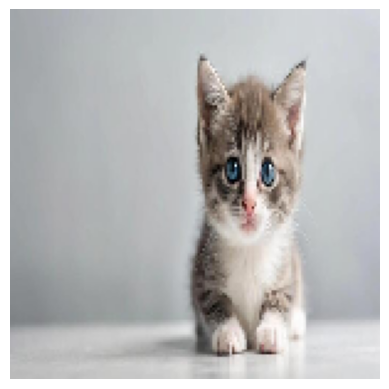

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Raw Prediction: [[1.6904592e-05]]
🐱 CAT
Confidence: 100.0 %


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

model = load_model("cat_dog_mobilenet.keras")

img_path = "cat.jpeg"

img = image.load_img(img_path, target_size=(150,150))

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Raw Prediction:", prediction)

if prediction[0][0] > 0.5:
    print("🐶 DOG")
    print("Confidence:", round(prediction[0][0] * 100, 2), "%")
else:
    print("🐱 CAT")
    print("Confidence:", round((1 - prediction[0][0]) * 100, 2), "%")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dog.jpeg to dog.jpeg


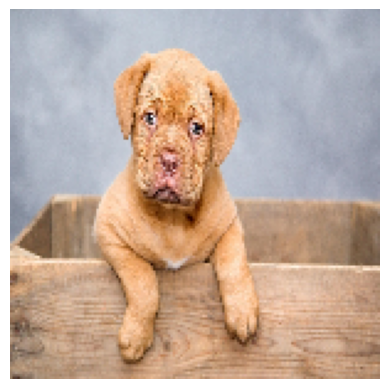

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Raw Prediction: [[0.9999944]]
🐶 DOG
Confidence: 100.0 %


In [71]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

model = load_model("cat_dog_mobilenet.keras")

img_path = "dog.jpeg"

img = image.load_img(img_path, target_size=(150,150))

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Raw Prediction:", prediction)

if prediction[0][0] > 0.5:
    print("🐶 DOG")
    print("Confidence:", round(prediction[0][0] * 100, 2), "%")
else:
    print("🐱 CAT")
    print("Confidence:", round((1 - prediction[0][0]) * 100, 2), "%")

In [72]:
from google.colab import files

uploaded = files.upload()

Saving cow.jpeg to cow.jpeg


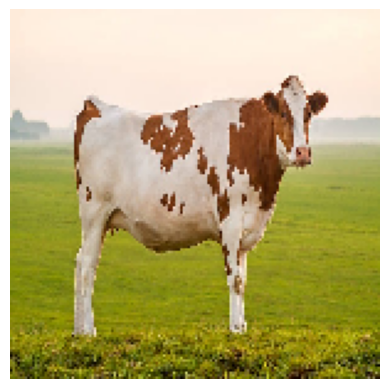

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Raw Prediction: [[0.99966455]]
🐶 DOG


In [74]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

model = load_model("cat_dog_mobilenet.keras")

img_path = "cow.jpeg"

img = image.load_img(img_path, target_size=(150,150))

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Raw Prediction:", prediction)

pred = prediction[0][0]

if pred > 0.9:
    print("🐶 DOG")

elif pred < 0.1:
    print("🐱 CAT")

else:
    print("❌ UNKNOWN / NOT CAT OR DOG")

In [75]:
from google.colab import files

files.download("cat_dog_mobilenet.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>